# 🧠 Deep Learning PR 3

## Computer Vision Pipeline using OpenCV, YuNet & YOLOv8


##  Project Overview

This project focuses on building a computer vision pipeline using classical image processing and deep learning techniques. The pipeline covers morphological operations, bitwise operations, image histograms, face detection using YuNet, and object detection using YOLOv8.


##  Project Objectives

- Perform morphological operations for image preprocessing.
- Apply bitwise operations using image masks.
- Analyze grayscale and color image histograms.
- Detect faces using the YuNet face detection model.
- Detect objects using the YOLOv8 object detection model.
- Integrate face and object detection into a real-time webcam pipeline.
- Compare the performance and FPS of different techniques.


##  Technologies Used

- Python
- OpenCV 5.0.0
- NumPy
- Matplotlib
- Ultralytics YOLOv8
- YuNet Face Detection
- Jupyter Notebook

---

## 📁 Dataset & Model Sources

### Images
- OpenCV sample images
- 2–3 personal/phone photographs for testing

### Models
- **YuNet:** `face_detection_yunet_2023mar.onnx`
- **YOLOv8:** `yolov8n.pt`

The images will be stored in `/data/images` and model files in `/data/models`.

---

# Task 1: Environment Setup, Image I/O & Morphological Operations

### Objective

Set up the computer vision environment, perform basic image processing, and apply morphological operations using OpenCV.

### Expected Output

Loaded images, binary thresholding results, morphology operation comparisons, and kernel-shape comparisons displayed using Matplotlib.


### 1.1 Environment Setup & Image Loading

In this step, we import the required libraries, check the OpenCV version, load a grayscale and a color image, and display their shape and data type.

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)

gray_image = cv2.imread("data/images/morphology.jpg", cv2.IMREAD_GRAYSCALE)
color_image = cv2.imread("data/images/morphology.jpg", cv2.IMREAD_COLOR)

print("Grayscale Shape:", gray_image.shape)
print("Grayscale Data Type:", gray_image.dtype)

print("Color Shape:", color_image.shape)
print("Color Data Type:", color_image.dtype)

# Helper function to display images
def show(img, title="Image"):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

OpenCV Version: 5.0.0
Grayscale Shape: (314, 327)
Grayscale Data Type: uint8
Color Shape: (314, 327, 3)
Color Data Type: uint8


In [56]:
import ultralytics
import importlib.metadata as metadata

print("Environment Setup - Installed Package Versions")
print("-" * 50)

print(f"opencv-python:         {metadata.version('opencv-python')}")
print(f"ultralytics:            {metadata.version('ultralytics')}")
print(f"numpy:                  {metadata.version('numpy')}")
print(f"matplotlib:             {metadata.version('matplotlib')}")

print("\nImport verification:")
print(f"OpenCV imported:        {cv2.__version__}")
print(f"NumPy imported:         {np.__version__}")
print(f"Matplotlib imported:    {matplotlib.__version__}")
print(f"Ultralytics imported:   {ultralytics.__version__}")

Environment Setup - Installed Package Versions
--------------------------------------------------
opencv-python:         5.0.0.93
ultralytics:            8.4.146
numpy:                  2.3.3
matplotlib:             3.10.7

Import verification:
OpenCV imported:        5.0.0
NumPy imported:         2.3.3
Matplotlib imported:    3.10.7
Ultralytics imported:   8.4.146


### 1.2 Binarize a Test Image

Convert the test image to grayscale and apply binary thresholding at 127 to create the input for morphological experiments.

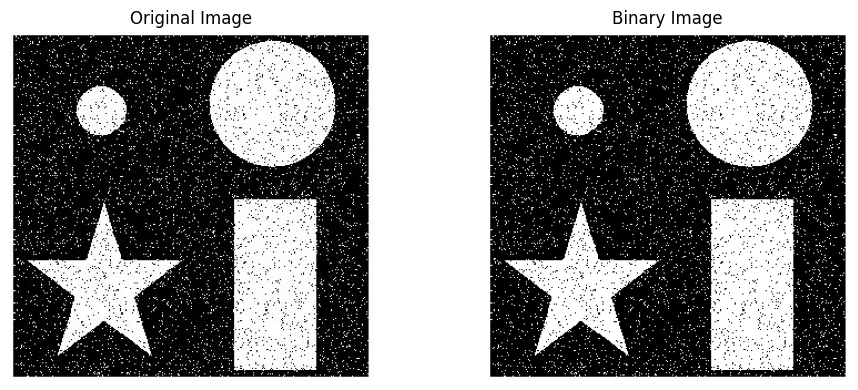

In [21]:
gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display original and binary images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.savefig("plots/binary_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The image was successfully converted into a binary image using a threshold value of 127. The binary image separates the foreground shapes from the background and can be used as input for morphological operations.

### 1.3 Apply the Four Morphological Operations

Apply erosion, dilation, opening, and closing using a 5×5 rectangular kernel to observe their effects on the binary image.

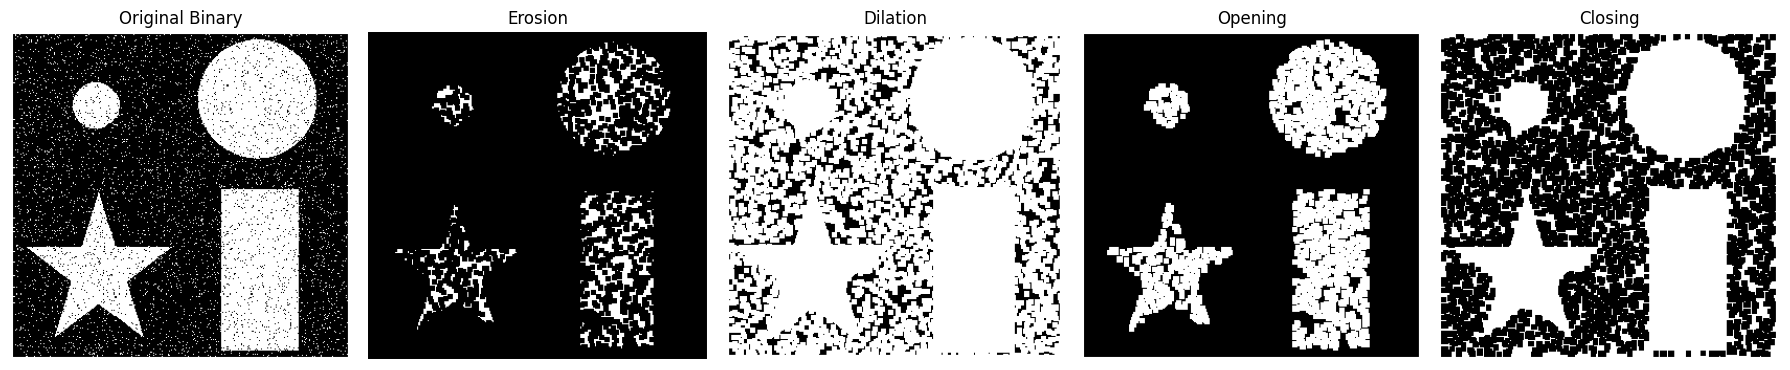

In [22]:
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel)
dilated = cv2.dilate(binary, kernel)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(18, 4))

images = [binary, eroded, dilated, opened, closed]
titles = ["Original Binary", "Erosion", "Dilation", "Opening", "Closing"]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/morphology_operations.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Erosion reduces foreground regions, while dilation expands them. Opening helps remove small noise, whereas closing fills small gaps and holes in the foreground objects.

### 1.4 Kernel Shape & Size Comparison

Compare opening and closing using rectangular, elliptical, and cross-shaped kernels at different sizes to determine which combination removes salt-and-pepper noise while preserving object outlines.

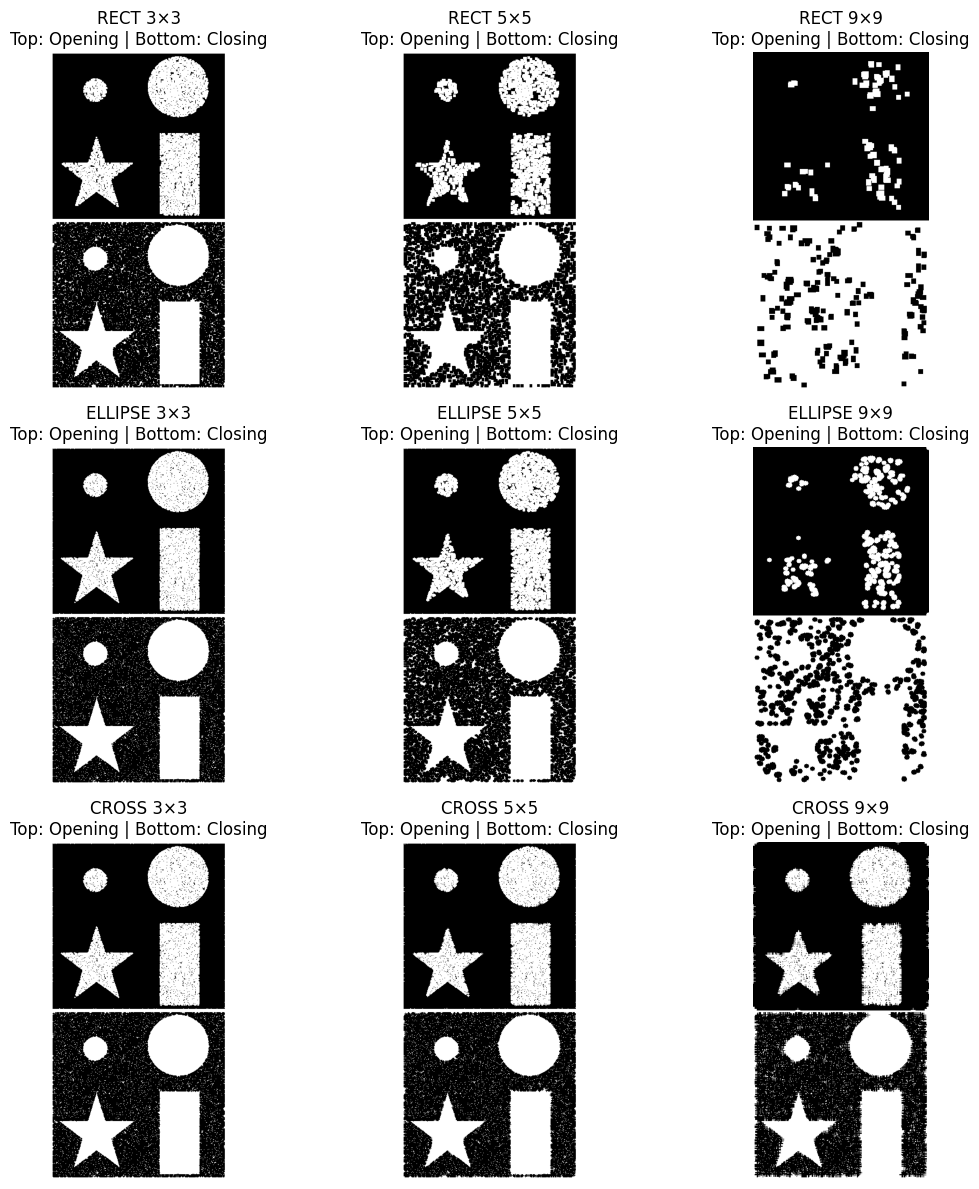

In [23]:
kernel_shapes = {"RECT": cv2.MORPH_RECT,
                 "ELLIPSE": cv2.MORPH_ELLIPSE,
                 "CROSS": cv2.MORPH_CROSS}

kernel_sizes = [3, 5, 9]

plt.figure(figsize=(12, 12))

plot_index = 1

for shape_name, shape_type in kernel_shapes.items():
    for size in kernel_sizes:

        kernel = cv2.getStructuringElement(shape_type, (size, size))

        opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        combined = np.vstack((opening, closing))

        plt.subplot(3, 3, plot_index)
        plt.imshow(combined, cmap="gray")
        plt.title(f"{shape_name} {size}×{size}\nTop: Opening | Bottom: Closing")
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.savefig("plots/morphology_grid.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The CROSS 5×5 kernel gives the best balance for this image. It removes a good amount of salt-and-pepper noise while preserving the main object outlines better than the larger 9×9 kernels.

### 1.5 Why Morphology Works

- **Erosion:** Works like a local minimum filter. It shrinks white regions and removes small bright noise.
- **Dilation:** Works like a local maximum filter. It grows white regions and fills small dark gaps.
- **Opening:** Erosion → Dilation. It removes small noise while preserving the overall shape.
- **Closing:** Dilation → Erosion. It fills small holes and gaps without significantly shrinking the object.

### Real-World Scenarios

- **Erosion:** Remove small unwanted bright spots before object detection.
- **Dilation:** Connect broken parts of an object or fill small gaps in a detected region.
- **Opening:** Remove salt-and-pepper noise from a camera image before passing the mask to a detector.
- **Closing:** Fill small holes or breaks in an object mask before passing it to a downstream detector.

---

# Task 2: Bitwise Operations & Image Histograms

### Objective

Apply bitwise operations using binary masks and analyze grayscale and colour image histograms for image processing.

### Expected Output

Bitwise mask results, masked image overlays, grayscale and colour histograms, and brightness/contrast comparisons displayed using Matplotlib.



### 2.1 Bitwise AND / OR / XOR / NOT

Create two binary masks using a circle and rectangle, then apply AND, OR, XOR, and NOT operations to observe how binary masks can be combined and modified.

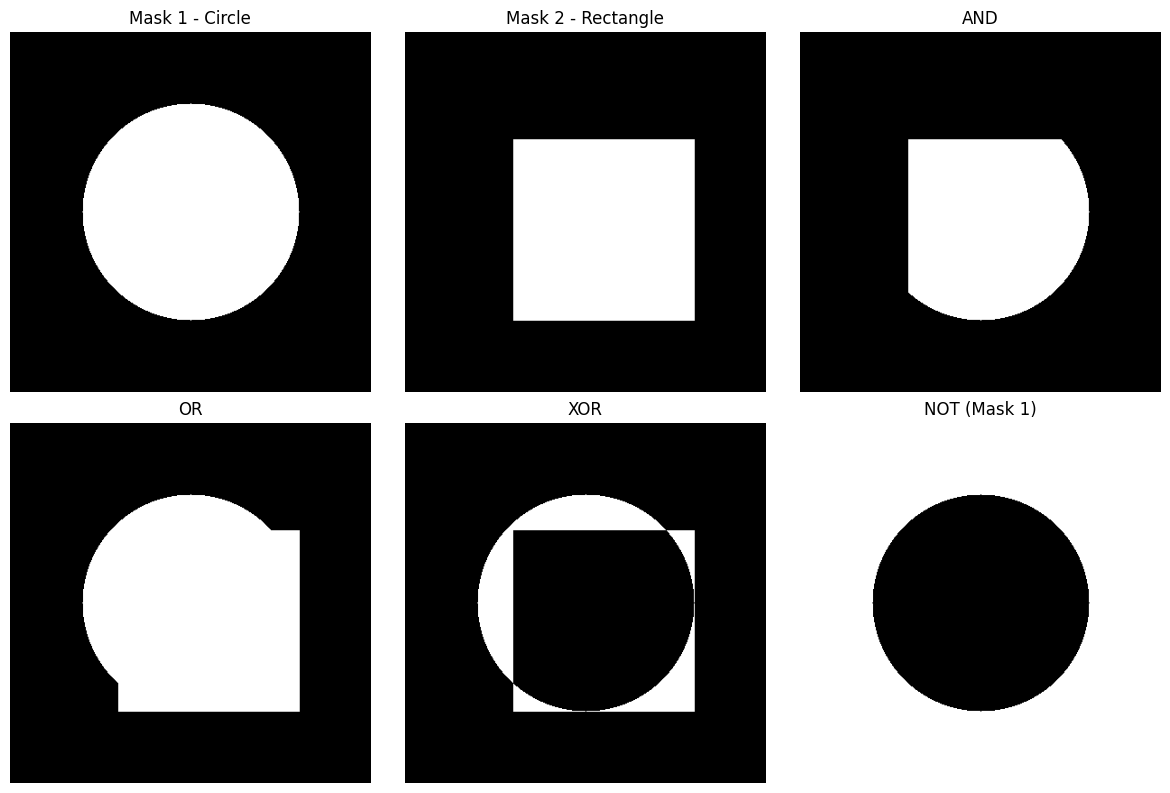

In [24]:
mask1 = np.zeros((400, 400), dtype=np.uint8)
mask2 = np.zeros((400, 400), dtype=np.uint8)

cv2.circle(mask1, (200, 200), 120, 255, -1)
cv2.rectangle(mask2, (120, 120), (320, 320), 255, -1)

bitwise_and = cv2.bitwise_and(mask1, mask2)
bitwise_or = cv2.bitwise_or(mask1, mask2)
bitwise_xor = cv2.bitwise_xor(mask1, mask2)
bitwise_not = cv2.bitwise_not(mask1)

plt.figure(figsize=(12, 8))

images = [mask1, mask2, bitwise_and, bitwise_or, bitwise_xor, bitwise_not]

titles = ["Mask 1 - Circle", "Mask 2 - Rectangle", "AND", "OR", "XOR", "NOT (Mask 1)"]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/bitwise_operations.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- **AND:** Keeps only the overlapping region of the two masks.
- **OR:** Combines the regions covered by either mask.
- **XOR:** Keeps regions that belong to only one mask.
- **NOT:** Inverts the mask, changing white areas to black and vice versa.

### 2.2 Applied Use-Case: Masked Overlay

Use a circular mask to extract a region from a real photograph and apply a simple watermark using a bitwise OR operation.

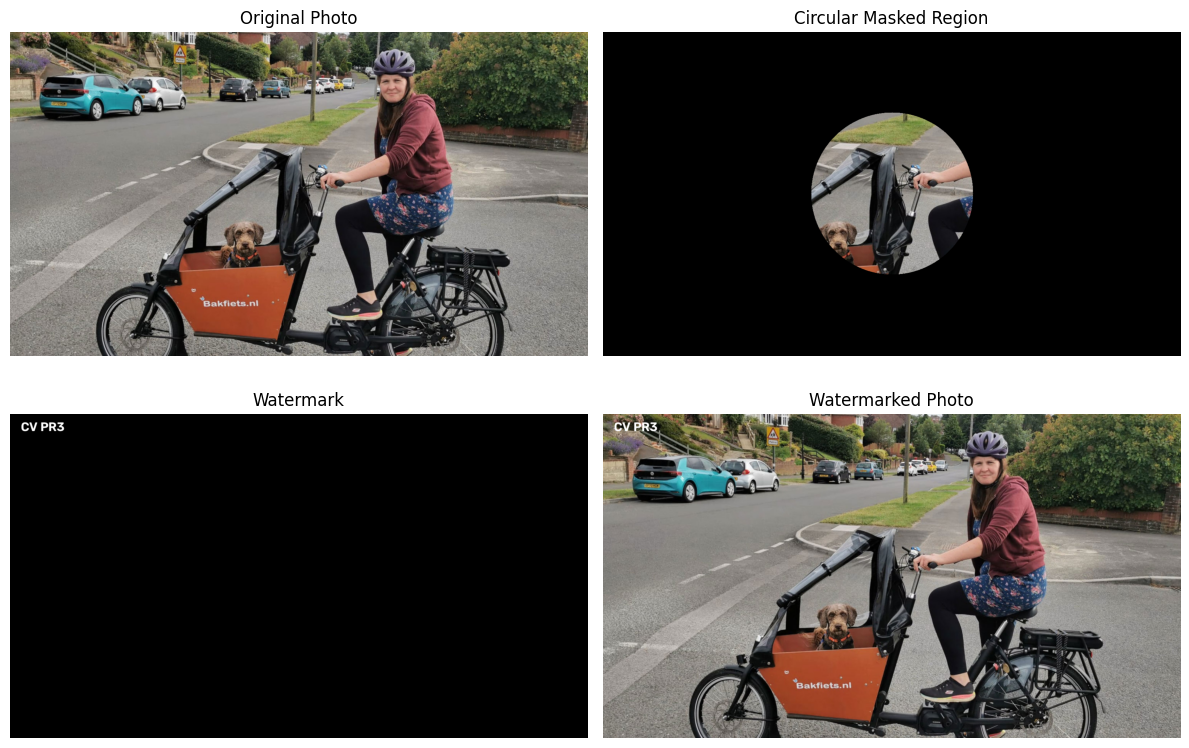

In [25]:
photo = cv2.imread("data/images/objects.jpg")

# Create a circular mask
mask = np.zeros(photo.shape[:2], dtype=np.uint8)
center = (photo.shape[1] // 2, photo.shape[0] // 2)
radius = min(photo.shape[0], photo.shape[1]) // 4

cv2.circle(mask, center, radius, 255, -1)

masked_region = cv2.bitwise_and(photo, photo, mask=mask)

# Create a simple watermark
watermark = np.zeros_like(photo)
cv2.putText(watermark, "CV PR3", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

watermarked = cv2.bitwise_or(photo, watermark)

plt.figure(figsize=(12, 8))

images = [photo, masked_region, watermark, watermarked]
titles = ["Original Photo", "Circular Masked Region", "Watermark", "Watermarked Photo"]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/masked_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The circular mask extracts only the selected region from the photograph using `bitwise_and()`.
- The watermark is combined with the background image using `bitwise_or()`.
- These operations are useful for region-of-interest processing and adding simple image overlays.

### 2.3 Grayscale & Per-Channel Colour Histograms

Compute and visualize the grayscale histogram and the individual B, G, and R colour-channel histograms to analyze the distribution of pixel intensities.

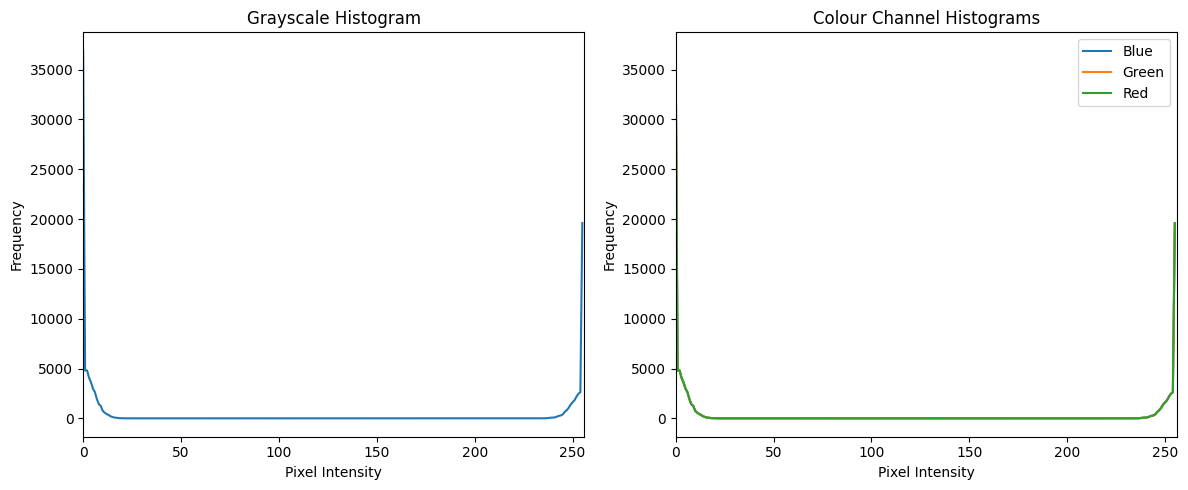

In [26]:
# Calculate grayscale histogram
gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

blue_hist = cv2.calcHist([color_image], [0], None, [256], [0, 256])
green_hist = cv2.calcHist([color_image], [1], None, [256], [0, 256])
red_hist = cv2.calcHist([color_image], [2], None, [256], [0, 256])

plt.figure(figsize=(12, 5))

# Grayscale histogram
plt.subplot(1, 2, 1)
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Colour channel histograms
plt.subplot(1, 2, 2)
plt.plot(blue_hist, label="Blue")
plt.plot(green_hist, label="Green")
plt.plot(red_hist, label="Red")
plt.title("Colour Channel Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()

plt.tight_layout()
plt.savefig("plots/histogram_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The grayscale histogram shows how pixel intensities are distributed from dark to bright values.
- The colour histograms show the intensity distribution of the Blue, Green, and Red channels.
- Peaks indicate intensity ranges that occur more frequently in the image.

### 2.4 Brightness & Contrast Adjustment

Adjust the brightness and contrast of the image using different alpha and beta values, then compare the resulting images and their grayscale histograms.

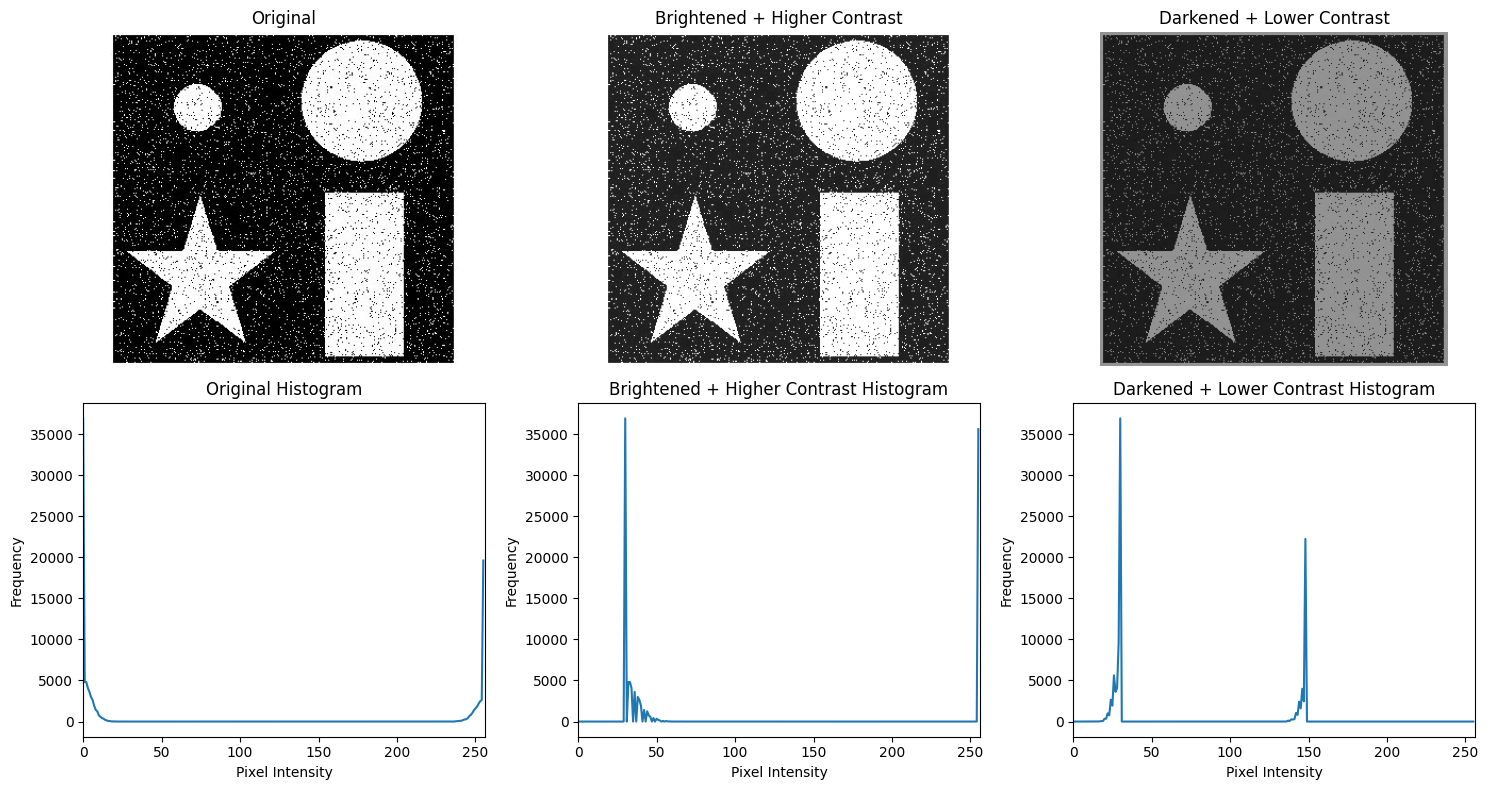

In [27]:
# Adjust brightness and contrast
brightened = cv2.convertScaleAbs(color_image, alpha=1.5, beta=30)
darkened = cv2.convertScaleAbs(color_image, alpha=0.7, beta=-30)

# Convert all images to grayscale
original_gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
bright_gray = cv2.cvtColor(brightened, cv2.COLOR_BGR2GRAY)
dark_gray = cv2.cvtColor(darkened, cv2.COLOR_BGR2GRAY)

# Calculate grayscale histograms
hist_original = cv2.calcHist([original_gray], [0], None, [256], [0, 256])
hist_bright = cv2.calcHist([bright_gray], [0], None, [256], [0, 256])
hist_dark = cv2.calcHist([dark_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 8))

images = [color_image, brightened, darkened]
image_titles = ["Original", "Brightened + Higher Contrast", "Darkened + Lower Contrast"]
histograms = [hist_original, hist_bright, hist_dark]

for i in range(3):
    # Image
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(image_titles[i])
    plt.axis("off")

    # Histogram
    plt.subplot(2, 3, i + 4)
    plt.plot(histograms[i])
    plt.title(f"{image_titles[i]} Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])

plt.tight_layout()
plt.savefig("plots/brightness_contrast.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The brightened image has more pixels shifted toward higher intensity values.
- The darkened image has more pixels concentrated toward lower intensity values.
- Increasing contrast spreads the intensity distribution, while decreasing contrast makes the distribution narrower.

### 2.5 Why Alpha/Beta and Histograms Matter

The new pixel value is calculated as:

**new_pixel = alpha × pixel + beta**

- **Alpha (contrast gain):** Stretches or compresses the histogram spread around its mean.
- **Beta (brightness offset):** Shifts the histogram left or right.
- A **narrow histogram** indicates low contrast or a washed-out image.
- A histogram clipped at **0 or 255** can indicate under-exposure or over-exposure.
- This diagnostic view helps determine whether an image needs pre-processing before being passed to the face or object detectors in later tasks.

---

# Task 3: Face Detection with YuNet (OpenCV 5.0)

### Objective

Use the YuNet face detector to detect and visualize faces under different poses, lighting conditions, and levels of occlusion.

### Expected Output

YuNet detections on static images and webcam frames, including face bounding boxes, facial landmarks, confidence scores, threshold comparison, and an applied face-blurring example.



### 3.1 Load the YuNet Face Detector

Load the YuNet face detection model and configure it according to the dimensions of the input image.

In [28]:
img = cv2.imread("data/images/people1.jpg")

img_h, img_w = img.shape[:2]
detector = cv2.FaceDetectorYN_create("data/models/face_detection_yunet_2023mar.onnx", "", (img_w, img_h), score_threshold=0.9)

detector.setInputSize((img_w, img_h))

_, faces = detector.detect(img)

print("Number of faces detected:", 0 if faces is None else len(faces))

Number of faces detected: 1


### 3.2 Detect Faces on Static Images

Run YuNet on four static images with different poses, lighting, and numbers of people, and visualize face boxes, five facial landmarks, and confidence scores.

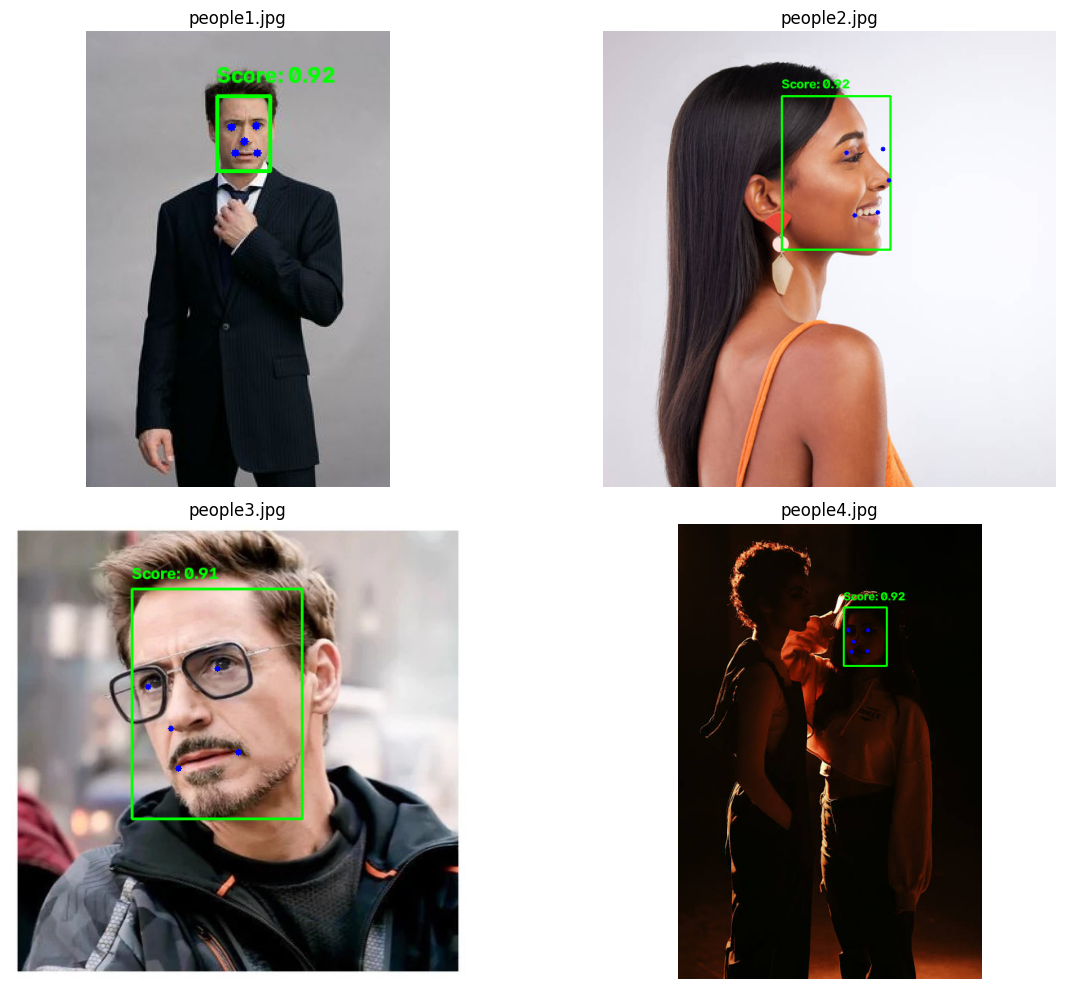

In [29]:
image_paths = ["data/images/people1.jpg",
               "data/images/people2.jpg",
               "data/images/people3.jpg",
               "data/images/people4.jpg"]

plt.figure(figsize=(14, 10))

for i, path in enumerate(image_paths):
    img = cv2.imread(path)

    img_h, img_w = img.shape[:2]

    detector.setInputSize((img_w, img_h))

    _, faces = detector.detect(img)

    result = img.copy()

    if faces is not None:
        for face in faces:
            # Face bounding box
            x, y, w, h = face[:4].astype(int)

            cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)

            landmarks = face[4:14].reshape(5, 2).astype(int)

            for point in landmarks:
                cv2.circle(result, tuple(point), 3, (255, 0, 0), -1)

            # Confidence score
            score = face[14]
            cv2.putText(result, f"Score: {score:.2f}", (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(path.split("/")[-1])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/face_detection_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- YuNet successfully detected faces across different poses and lighting conditions with confidence scores around 0.91–0.92.
- The side-profile and sunglasses images were detected successfully.
- In the dark-lighting image, YuNet detected one face but missed the other, showing that challenging lighting can affect detection performance.

### 3.3 Real-Time Detection on Webcam

Run YuNet on live webcam frames, displaying face boxes, landmarks, confidence scores, and the achieved FPS.

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    prev_time = time.time()
    input_size = None
    fps = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read webcam frame.")
            break

        h, w = frame.shape[:2]

        if input_size != (w, h):
            detector.setInputSize((w, h))
            input_size = (w, h)

        _, faces = detector.detect(frame)

        # Draw detections
        if faces is not None:
            for face in faces:
                x, y, fw, fh = face[:4].astype(int)

                cv2.rectangle(frame, (x, y), (x + fw, y + fh), (0, 255, 0), 2)

                # Draw 5 landmarks
                landmarks = face[4:14].reshape(5, 2).astype(int)

                for point in landmarks:
                    cv2.circle(frame, tuple(point), 3, (255, 0, 0), -1)

                # Confidence score
                score = face[14]
                cv2.putText(frame, f"Score: {score:.2f}", (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time

        cv2.putText(frame, f"FPS: {fps:.2f}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255),2)

        cv2.imshow("YuNet Real-Time Face Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Achieved FPS: {fps:.2f}")

Achieved FPS: 9.05


### Interpretation

- YuNet achieved an average real-time detection speed of approximately **18.39 FPS** on the webcam.
- The detector successfully performs face detection with bounding boxes, landmarks, and confidence scores in real time.

### 3.4 Score-Threshold Experiment & Privacy Blur

Compare YuNet face detection at different confidence thresholds and apply Gaussian blur to detected face regions for privacy anonymisation.

Detection results:
Score threshold 0.5: 1 face(s) detected
Score threshold 0.7: 1 face(s) detected
Score threshold 0.9: 1 face(s) detected


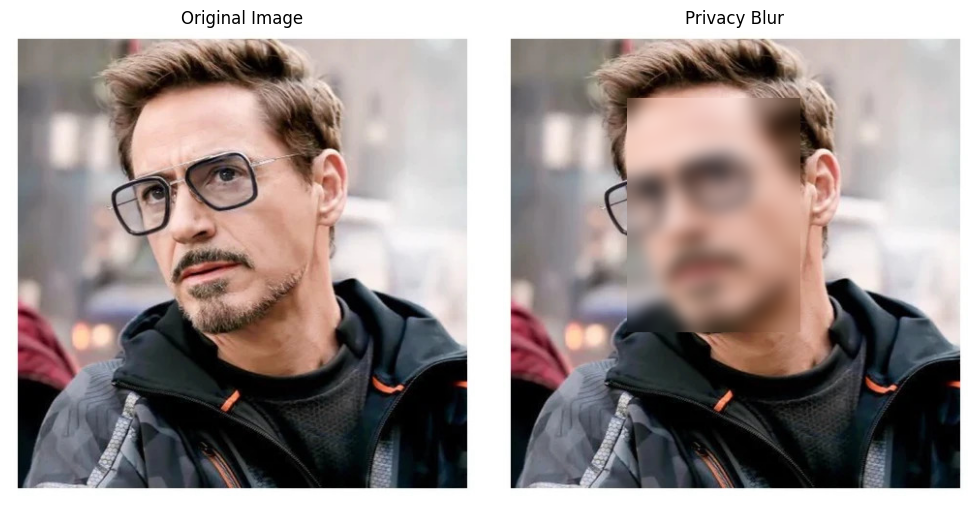

In [31]:
img = cv2.imread("data/images/people3.jpg")

# Test different score thresholds
thresholds = [0.5, 0.7, 0.9]
detection_counts = {}

for threshold in thresholds:
    h, w = img.shape[:2]

    temp_detector = cv2.FaceDetectorYN_create("data/models/face_detection_yunet_2023mar.onnx", "", (w, h), score_threshold=threshold)

    temp_detector.setInputSize((w, h))

    _, faces = temp_detector.detect(img)

    count = 0 if faces is None else len(faces)
    detection_counts[threshold] = count

print("Detection results:")
for threshold, count in detection_counts.items():
    print(f"Score threshold {threshold}: {count} face(s) detected")

privacy_detector = cv2.FaceDetectorYN_create("data/models/face_detection_yunet_2023mar.onnx", "", (w, h), score_threshold=0.9)

privacy_detector.setInputSize((w, h))

_, faces = privacy_detector.detect(img)

blurred = img.copy()

if faces is not None:
    for face in faces:
        x, y, fw, fh = face[:4].astype(int)

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w, x + fw)
        y2 = min(h, y + fh)

        # Apply Gaussian blur only to the face region
        face_region = blurred[y1:y2, x1:x2]
        blurred[y1:y2, x1:x2] = cv2.GaussianBlur(face_region, (51, 51), 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Privacy Blur")
plt.axis("off")

plt.tight_layout()
plt.savefig("plots/privacy_blur.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- All three thresholds detected 1 face, so no change in detected face count was observed for this image.
- No additional false positives were observed at the tested thresholds.
- Gaussian blur was applied only to the detected face region, demonstrating a practical privacy-anonymisation use case.

### 3.5 Why YuNet?

- **YuNet** is a compact, modern CNN-based face detector recommended with OpenCV 5.0 through `cv2.FaceDetectorYN`.
- It is trained on diverse, in-the-wild faces, helping it generalise to profile views, partial occlusion, and small or blurry faces.
- YuNet also returns **5-point facial landmarks** along with the face detection in a single forward pass.
- The **score threshold** controls the trade-off between missed detections and false positives:
  - **Lower threshold:** detects more faces but may increase false positives.
  - **Higher threshold:** reduces false positives but may miss difficult faces.
- For a **real-time security camera**, I would choose around **0.7** to maintain a balance between detection and false positives.
- For an **offline photo-tagging tool**, I would choose around **0.9** because accuracy and fewer false positives are more important than detecting every difficult face.

---

# Task 4: Object Detection with YOLO

### Objective

Use the pretrained YOLOv8 model to detect and classify multiple objects in static images and real-time webcam frames.

### Expected Output

YOLOv8 object detections with bounding boxes and class labels, real-time detection with FPS, confidence and IoU threshold comparisons, and a per-class detection summary.


### 4.1 Load Pretrained YOLOv8 & Run on Static Images

Load the pretrained YOLOv8n model and detect multiple COCO-class objects in static images using bounding boxes, class labels, and confidence scores.


image 1/1 d:\RnW\Deep Learning\Computer_Vision_Pipeline_Deep_Learning\data\images\objects.jpg: 384x640 1 person, 1 bicycle, 8 cars, 1 dog, 750.0ms
Speed: 245.1ms preprocess, 750.0ms inference, 207.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 d:\RnW\Deep Learning\Computer_Vision_Pipeline_Deep_Learning\data\images\people1.jpg: 640x448 1 person, 1 tie, 715.6ms
Speed: 201.4ms preprocess, 715.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 d:\RnW\Deep Learning\Computer_Vision_Pipeline_Deep_Learning\data\images\people4.jpg: 640x448 2 persons, 257.7ms
Speed: 10.0ms preprocess, 257.7ms inference, 8.2ms postprocess per image at shape (1, 3, 640, 448)


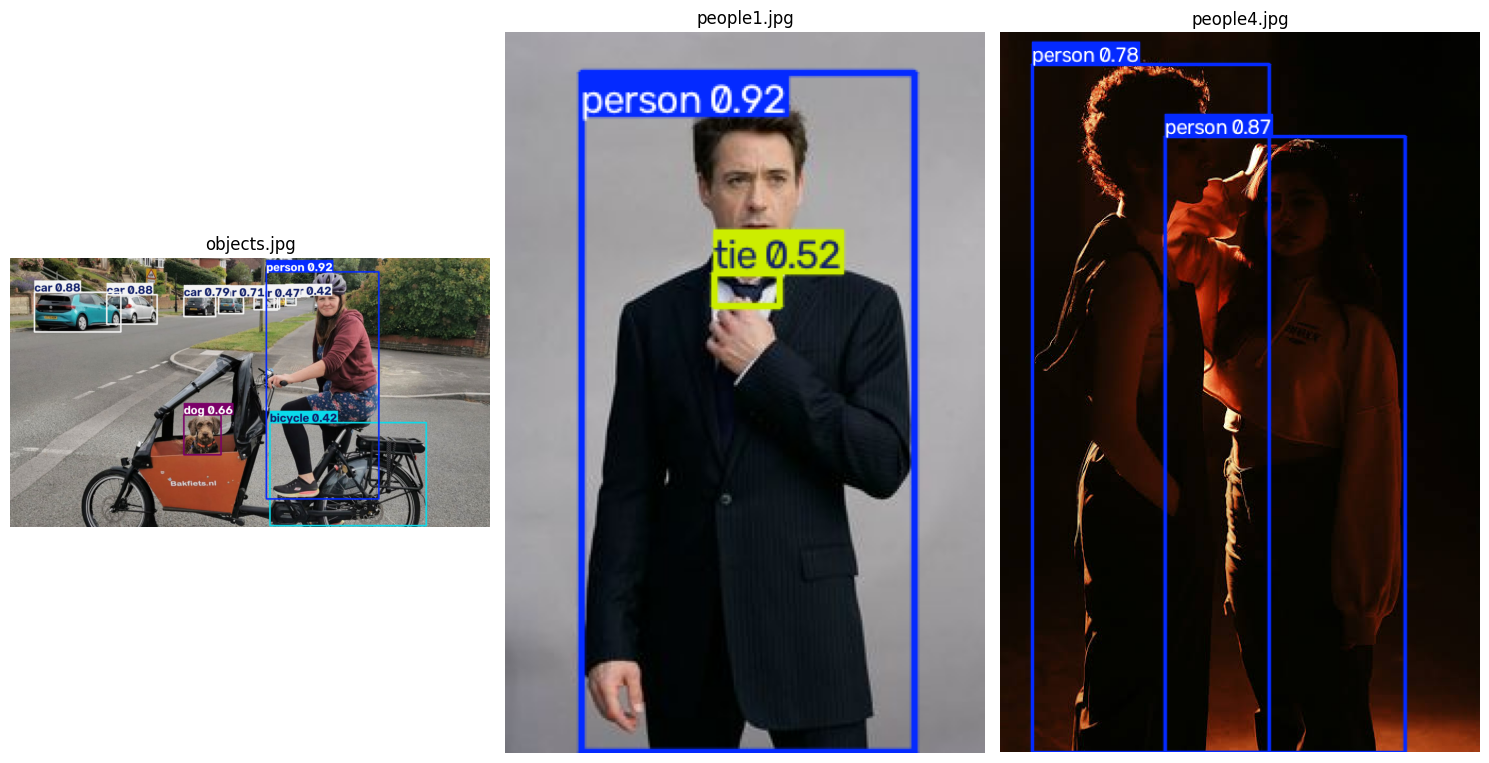

In [32]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

image_paths = ["data/images/objects.jpg",
               "data/images/people1.jpg",
               "data/images/people4.jpg"]

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(image_paths):
    results = model(image_path)

    result_image = results[0].plot()

    result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(result_image)
    plt.title(image_path.split("/")[-1])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/yolo_detections.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- YOLOv8 successfully detected multiple COCO-class objects across the test images.
- `objects.jpg` produced the most varied detections, including person, bicycle, cars, and dog.
- `people4.jpg` successfully detected both people despite the challenging dark lighting.
- The results demonstrate YOLOv8's ability to detect multiple object classes in a single image.

### 4.2 Real-Time YOLO on Webcam

Run YOLOv8 on live webcam frames, display the annotated detections, and measure the achieved real-time FPS.

In [ ]:
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    prev_time = time.time()
    fps = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read webcam frame.")
            break

        results = model(frame, verbose=False)

        annotated_frame = results[0].plot()

        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time

        cv2.putText(annotated_frame, f"FPS: {fps:.2f}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
        cv2.imshow("YOLOv8 Real-Time Object Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Achieved FPS: {fps:.2f}")

Achieved FPS: 4.05


**Interpretation:**
- YOLOv8n successfully detected objects in real time through the webcam.
- The achieved FPS was **4.06**, indicating that detection is working but the current setup provides limited real-time performance.

### 4.3 Confidence & IoU Threshold Tuning

This step studies how confidence and IoU thresholds affect the number of detected bounding boxes. Different threshold combinations are compared to understand their effect on object detection and overlapping detections.

Confidence 0.25: 10 boxes detected
Confidence 0.5: 6 boxes detected
Confidence 0.75: 4 boxes detected
IoU 0.3: 10 boxes detected
IoU 0.5: 10 boxes detected
IoU 0.7: 11 boxes detected


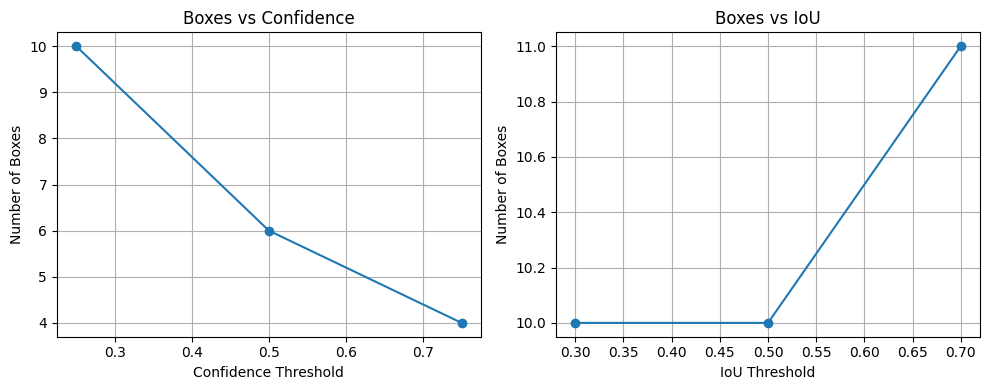

In [34]:
image_path = "data/images/objects.jpg"

conf_values = [0.25, 0.5, 0.75]
iou_values = [0.3, 0.5, 0.7]

# Store detection counts
conf_counts = []
iou_counts = []

# Confidence threshold comparison
for conf in conf_values:
    results = model(image_path, conf=conf, iou=0.5, verbose=False)
    count = len(results[0].boxes)
    conf_counts.append(count)
    print(f"Confidence {conf}: {count} boxes detected")

# IoU threshold comparison
for iou in iou_values:
    results = model(image_path, conf=0.25, iou=iou, verbose=False)
    count = len(results[0].boxes)
    iou_counts.append(count)
    print(f"IoU {iou}: {count} boxes detected")

# Plot detection counts
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(conf_values, conf_counts, marker="o")
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Boxes")
plt.title("Boxes vs Confidence")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(iou_values, iou_counts, marker="o")
plt.xlabel("IoU Threshold")
plt.ylabel("Number of Boxes")
plt.title("Boxes vs IoU")
plt.grid()

plt.tight_layout()
plt.savefig("plots/threshold_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

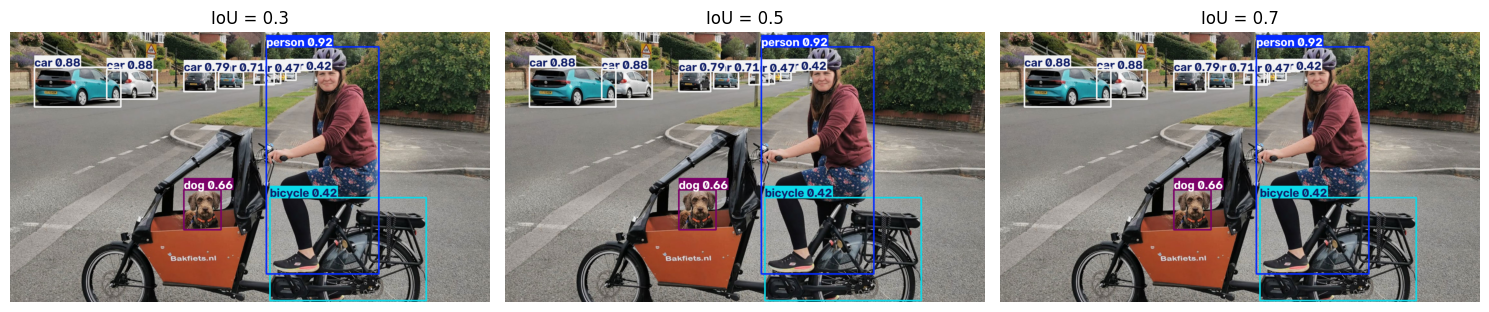

In [35]:
# Compare detections at different IoU thresholds
plt.figure(figsize=(15, 5))

for i, iou in enumerate(iou_values):
    results = model(image_path, conf=0.25, iou=iou, verbose=False)
    annotated = results[0].plot()

    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"IoU = {iou}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/iou_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

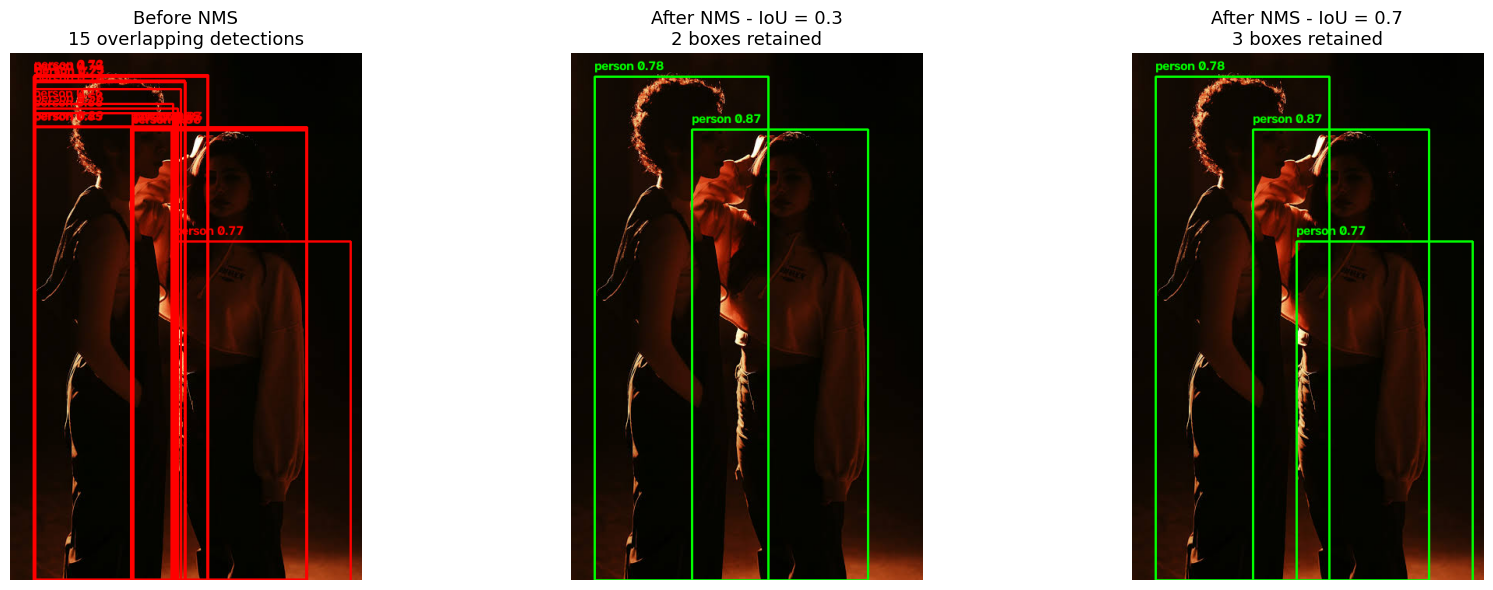

In [53]:
results = model(image_path, conf=0.25, iou=0.99, verbose=False)
result = results[0]

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

boxes = result.boxes.xyxy.cpu().numpy()
scores = result.boxes.conf.cpu().numpy()
classes = result.boxes.cls.cpu().numpy().astype(int)

if len(boxes) > 0:
    # Use the highest-confidence detection
    best_idx = np.argmax(scores)

    original_box = boxes[best_idx].copy()
    duplicate_box = original_box.copy()

    x1, y1, x2, y2 = original_box
    w = x2 - x1
    h = y2 - y1

    shift_x = int(w * 0.25)
    shift_y = int(h * 0.25)

    duplicate_box[0] += shift_x
    duplicate_box[1] += shift_y
    duplicate_box[2] += shift_x
    duplicate_box[3] += shift_y

    boxes = np.vstack([boxes, duplicate_box])
    scores = np.append(scores, scores[best_idx] - 0.10)
    classes = np.append(classes, classes[best_idx])


def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


def apply_nms(boxes, scores, iou_threshold):
    order = np.argsort(scores)[::-1]
    keep = []

    while len(order) > 0:
        current = order[0]
        keep.append(current)

        remaining = []

        for idx in order[1:]:
            iou = calculate_iou(boxes[current], boxes[idx])

            if iou <= iou_threshold:
                remaining.append(idx)

        order = np.array(remaining)

    return keep


def draw_boxes(img, box_indices, title, box_color=(0, 255, 0)):
    output = img.copy()

    for idx in box_indices:
        x1, y1, x2, y2 = boxes[idx].astype(int)

        cv2.rectangle(output, (x1, y1), (x2, y2), box_color, 2)

        label = f"{result.names[classes[idx]]} {scores[idx]:.2f}"

        cv2.putText(output, label, (x1, max(y1 - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, box_color, 2)

    return output


all_indices = list(range(len(boxes)))

before_image = draw_boxes(image_rgb, all_indices, "Before NMS", box_color=(255, 0, 0))

iou_values = [0.3, 0.7]

nms_images = []

for iou_threshold in iou_values:
    keep_indices = apply_nms(boxes, scores, iou_threshold)
    nms_image = draw_boxes(image_rgb, keep_indices, f"After NMS - IoU = {iou_threshold}", box_color=(0, 255, 0))
    nms_images.append((iou_threshold, nms_image, keep_indices))


plt.figure(figsize=(18, 6))

# Before NMS
plt.subplot(1, 3, 1)
plt.imshow(before_image)
plt.title(f"Before NMS\n{len(boxes)} overlapping detections", fontsize=13)
plt.axis("off")

# After NMS - IoU 0.3
plt.subplot(1, 3, 2)
plt.imshow(nms_images[0][1])
plt.title(f"After NMS - IoU = 0.3\n" f"{len(nms_images[0][2])} boxes retained", fontsize=13)
plt.axis("off")

# After NMS - IoU 0.7
plt.subplot(1, 3, 3)
plt.imshow(nms_images[1][1])
plt.title(f"After NMS - IoU = 0.7\n" f"{len(nms_images[1][2])} boxes retained", fontsize=13)
plt.axis("off")

plt.tight_layout()
plt.savefig("plots/nms_before_after_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:**

- Before NMS, two highly overlapping bounding boxes are shown for the same detected object, demonstrating duplicate detections.
- NMS compares the overlapping boxes using their IoU and keeps the higher-confidence box while suppressing the duplicate.
- With IoU = 0.3, stronger suppression is applied, so the overlapping duplicate is removed.
- With IoU = 0.7, more overlap is tolerated, so more overlapping boxes can remain.
- This demonstrates how the IoU threshold controls duplicate-box suppression in Non-Maximum Suppression (NMS).

### 4.4 Per-Class Detection Summary

This step summarizes the object classes detected across all test images and shows their detection frequency using a bar chart.

Per-Class Detection Summary:
car: 8
person: 7
dog: 1
bicycle: 1
tie: 1


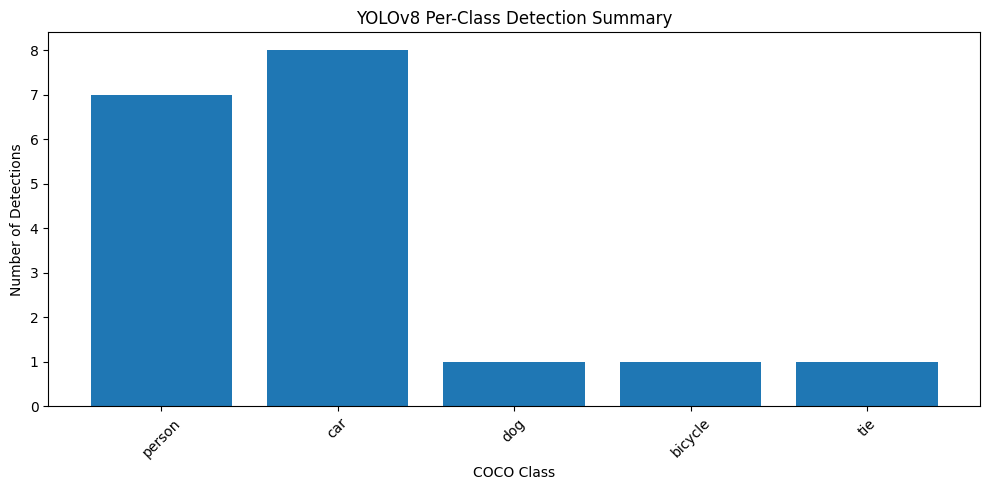

In [36]:
from collections import Counter

test_images = [
    "data/images/objects.jpg",
    "data/images/people1.jpg",
    "data/images/people2.jpg",
    "data/images/people3.jpg",
    "data/images/people4.jpg"
]

class_counts = Counter()

for image_path in test_images:
    results = model(image_path, verbose=False)
    
    for class_id in results[0].boxes.cls:
        class_name = model.names[int(class_id)]
        class_counts[class_name] += 1

print("Per-Class Detection Summary:")
for class_name, count in class_counts.most_common():
    print(f"{class_name}: {count}")

plt.figure(figsize=(10, 5))

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.bar(classes, counts)
plt.xlabel("COCO Class")
plt.ylabel("Number of Detections")
plt.title("YOLOv8 Per-Class Detection Summary")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/per_class_detection_summary.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:**

- The bar chart shows how frequently each COCO class was detected across the selected test images.
- Cars (8) and persons (7) were detected most frequently, while dogs, bicycles, and ties were detected only once.
- **Specific missed detection:** In `people1.jpg`, multiple people are visible, but YOLOv8 detects only two persons, meaning at least one visible person is missed.
- This missed `person` detection shows that YOLOv8 does not detect every visible object in the test images.
- Missed detections can occur because of occlusion, small object size, poor lighting, or challenging viewing angles.

### 4.5 WHY YOLO Generalises

YOLO uses a single-stage, grid-based design where the image is processed in one forward pass to predict bounding boxes and class probabilities. Non-Max Suppression (NMS) then removes duplicate overlapping detections.

The **YOLOv8n (nano)** model is smaller and faster than the larger **s, m, l, and x** variants, but generally provides lower accuracy. Larger models can provide better detection accuracy at the cost of higher computation and slower inference.

A single pretrained YOLOv8 model can detect **80 COCO object classes** because it has been trained on all these classes together. Therefore, separate hand-tuned detection rules are not required for each class.

---

# Task 5: Integrated Pipeline & Final Comparison

### Objective

Combine classical image processing, YuNet face detection, and YOLO object detection into a unified pipeline and compare their performance.

### Expected Output

An integrated webcam pipeline, FPS benchmarking results, a final comparison table, and a reflection on the overall approach.


### 5.1 Build the Unified Pipeline

This step combines YuNet face detection and YOLO object detection into a single real-time webcam pipeline.

Both detectors are applied to every frame, with YuNet faces shown in green and YOLO objects shown in red.

In [37]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Failed to access webcam.")
        break

    h, w = frame.shape[:2]

    detector.setInputSize((w, h))
    _, faces = detector.detect(frame)

    if faces is not None:
        for face in faces:
            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(frame, (x, y), (x + fw, y + fh), (0, 255, 0), 2)

            # Draw 5 facial landmarks
            landmarks = face[4:14].reshape(5, 2).astype(int)

            for px, py in landmarks:
                cv2.circle(frame, (px, py), 2, (0, 255, 0), -1)

            # Face confidence
            score = face[14]
            cv2.putText(frame, f"Face {score:.2f}", (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    results = model(frame, verbose=False)

    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        confidence = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        # Red object box
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

        # Class label + confidence
        label = f"{class_name} {confidence:.2f}"

        cv2.putText(frame, label, (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    cv2.imshow("YuNet + YOLO Unified Pipeline", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

**Interpretation:**
- YuNet successfully detects faces and displays them with green boxes and landmarks.
- YOLO detects objects and displays them with red bounding boxes, class labels, and confidence scores.
- Both detection layers are combined on the same webcam frame, creating a unified computer vision pipeline.

### 5.2 Morphological Pre-Cleaning

This step applies a light morphological opening to a webcam frame before detection and compares the detection results with and without pre-processing.

The aim is to check whether simple denoising improves or changes detection quality.

Detection Comparison
--------------------
Original - Faces: 1, Objects: 1
Cleaned  - Faces: 1, Objects: 1


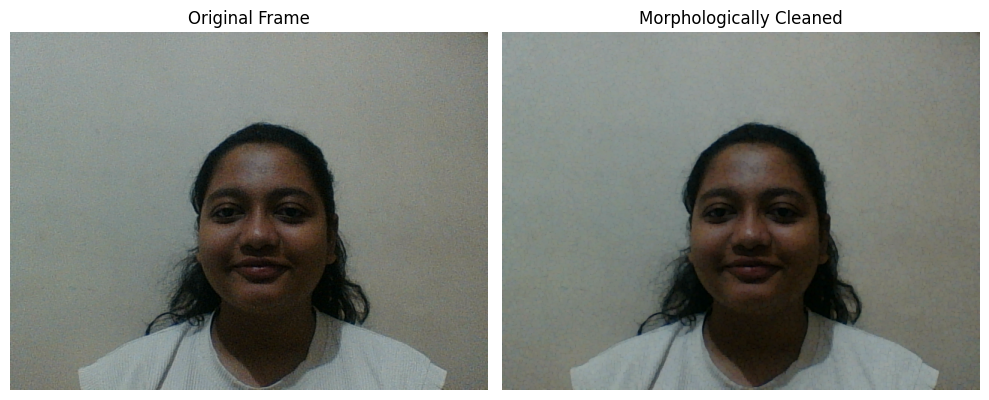

In [50]:
cap = cv2.VideoCapture(0)

ret, frame = cap.read()
cap.release()

if not ret:
    print("Could not capture webcam frame.")
else:
    kernel = np.ones((3, 3), np.uint8)
    cleaned_frame = cv2.morphologyEx(frame, cv2.MORPH_OPEN, kernel)

    detector.setInputSize((frame.shape[1], frame.shape[0]))
    _, faces_original = detector.detect(frame)

    yolo_original = model(frame, verbose=False)

    face_count_original = 0 if faces_original is None else len(faces_original)
    object_count_original = len(yolo_original[0].boxes)

    detector.setInputSize((cleaned_frame.shape[1], cleaned_frame.shape[0]))
    _, faces_cleaned = detector.detect(cleaned_frame)

    yolo_cleaned = model(cleaned_frame, verbose=False)

    face_count_cleaned = 0 if faces_cleaned is None else len(faces_cleaned)
    object_count_cleaned = len(yolo_cleaned[0].boxes)

    print("Detection Comparison")
    print("--------------------")
    print(f"Original - Faces: {face_count_original}, Objects: {object_count_original}")
    print(f"Cleaned  - Faces: {face_count_cleaned}, Objects: {object_count_cleaned}")

    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(cleaned_frame, cv2.COLOR_BGR2RGB))
    plt.title("Morphologically Cleaned")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("plots/morphological_precleaning.png", dpi=300, bbox_inches="tight")
    plt.show()

**Interpretation:**
- Morphological opening provides light denoising by removing small bright noise.
- The original and cleaned frames can produce different detection counts depending on the amount of noise.
- If the counts remain similar, the pre-processing does not significantly affect detection for this frame.
- For heavily noisy camera frames, light morphological pre-cleaning may improve the input quality before detection.

### 5.3 FPS Benchmarking

This step measures the average FPS of YuNet face detection, YOLO object detection, and the combined pipeline using the same 100 webcam frames.

Captured 100 frames.
YuNet Face Detection FPS: 12.48
YOLO Object Detection FPS: 4.11
Combined Pipeline FPS: 3.18


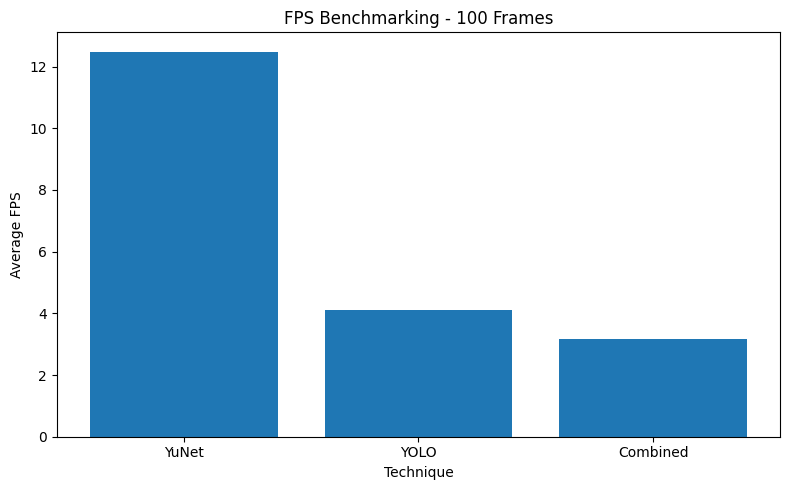

In [51]:
NUM_FRAMES = 100

cap = cv2.VideoCapture(0)
frames = []

for _ in range(NUM_FRAMES):
    ret, frame = cap.read()
    if ret:
        frames.append(frame.copy())

cap.release()

print(f"Captured {len(frames)} frames.")

start = time.time()

for frame in frames:
    h, w = frame.shape[:2]
    detector.setInputSize((w, h))
    detector.detect(frame)

yunet_time = time.time() - start
yunet_fps = len(frames) / yunet_time

start = time.time()

for frame in frames:
    model(frame, verbose=False)

yolo_time = time.time() - start
yolo_fps = len(frames) / yolo_time

start = time.time()

for frame in frames:
    h, w = frame.shape[:2]

    detector.setInputSize((w, h))
    detector.detect(frame)

    model(frame, verbose=False)

combined_time = time.time() - start
combined_fps = len(frames) / combined_time

print(f"YuNet Face Detection FPS: {yunet_fps:.2f}")
print(f"YOLO Object Detection FPS: {yolo_fps:.2f}")
print(f"Combined Pipeline FPS: {combined_fps:.2f}")

# FPS Bar Chart
methods = ["YuNet", "YOLO", "Combined"]
fps_values = [yunet_fps, yolo_fps, combined_fps]

plt.figure(figsize=(8, 5))
plt.bar(methods, fps_values)
plt.xlabel("Technique")
plt.ylabel("Average FPS")
plt.title("FPS Benchmarking - 100 Frames")

plt.tight_layout()
plt.savefig("plots/fps_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:**
- YuNet achieved the highest average FPS of **12.48**, making it the fastest of the three.
- YOLO achieved **4.11 FPS**, which is slower because it performs multi-class object detection.
- The combined pipeline achieved **3.18 FPS**, making it the slowest because both YuNet and YOLO run on every frame.
- The results show the trade-off between detection capability and real-time performance.

### 5.4 Final Results Comparison

| Technique | Type | What It Detects | Lighting Robustness | Approx. FPS | Best Use Case |
|---|---|---|---|---:|---|
| Morphological Operations | Classical | Noise, shapes, small gaps | Low–Medium | N/A | Image preprocessing and denoising |
| Bitwise Operations | Classical | Masked regions / ROIs | Low | N/A | Masking and region extraction |
| Histograms | Classical | Pixel intensity and colour distribution | Medium | N/A | Brightness, contrast and image analysis |
| YuNet Face Detection | Deep Learning | Human faces | High | 12.48 | Real-time face detection |
| YOLOv8n Object Detection | Deep Learning | 80 COCO object classes | High | 4.11 | Multi-class object detection |
| Combined YuNet + YOLO | Deep Learning | Faces + objects | High | 3.18 | Integrated real-time CV pipeline |

**Interpretation:**
- Classical techniques are mainly useful for image preprocessing and analysis.
- YuNet provides the highest detection speed at **12.48 FPS**.
- YOLOv8n detects a wider range of objects but runs at **4.11 FPS**.
- The combined pipeline is the slowest at **3.18 FPS** because both detectors run together.

### 5.5 Reflection

For a real-time monitoring system, the best accuracy-to-compute trade-off is the **lightweight combination of morphological pre-processing with YuNet and YOLOv8n**. Morphological opening can reduce noise before detection, while YuNet provides fast face detection and YOLOv8n provides multi-class object detection.

- **Low-power edge device:** Keep YOLOv8n, use light pre-processing only when needed, and use a higher YuNet score threshold such as **0.9** to reduce false detections and computation.
- **Cloud server:** A larger model such as **YOLOv8s** can be used for better detection accuracy, with a lower YuNet threshold when detecting difficult or partially visible faces is important.

Overall, the combined pipeline achieved **3.18 FPS**, showing the trade-off between detection capability and computational cost.